<a href="https://colab.research.google.com/github/Hajer5503/Esprit-PI-4DS5-AgriSmart/blob/feature%2Firrigation-rl/modules/irrigation_rl/notebooks/Layer2_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Irrigation Optimization — Layer 2: RL Control Agent
## Context

Layer 1 answers: *"What will happen tomorrow?"*
→ Predicts `sm_root(t+1)` and `ET₀(t+1)` from weather + soil sensors.

Layer 2 answers: *"What should we do about it?"*
→ Learns an optimal irrigation policy from those predictions.

---

## Business Objective

Train a Reinforcement Learning agent that:
- **Maintains soil moisture in the optimal band** (avoids crop stress)
- **Minimises water waste** (no over-irrigation)
- **Adapts to growth stage** (Kc varies across the wheat season)
- **Operates autonomously** with decision latency < 5 seconds

---

## Why Reinforcement Learning?

A rule-based scheduler (irrigate = ETc − precip) is static — it cannot:
- Learn from past seasons
- Adapt to soil memory effects (previous irrigation still draining)
- Balance competing objectives (yield vs water cost)
- Handle partial observability (sensors may be noisy)

RL learns a **policy** π(s) → a that maximises long-term cumulative reward,
not just the immediate best action. Over multiple seasons it discovers
irrigation strategies that no hand-crafted rule can match.

---

## MDP Formulation

We model irrigation scheduling as a **Markov Decision Process (MDP)**:

| Component | Definition |
|-----------|-----------|
| **State S** | `[ET₀, precip, sm_shallow, sm_deep, Kc, growth_stage, day_of_season]` |
| **Action A** | Discrete: `{0, 5, 10, 15, 20}` mm/day |
| **Reward R** | Multi-objective: stress penalty + excess penalty + water cost |
| **Transition** | FAO-56 soil water balance: SM(t+1) = SM(t) + precip + irr − ETc |
| **Episode** | One complete wheat season (sowing → harvest, ~228 days) |

---

## Connection to Layer 1

```
Layer 1 Output               Layer 2 Input (State)
─────────────────────────    ──────────────────────────────────
sm_root(t+1) predicted   →   sm_shallow, sm_deep  (soil state)
ET₀(t+1) predicted       →   ET₀                 (atmospheric demand)
                             precip, Kc, growth_stage, day_of_season
```

Layer 1 predictions replace raw sensor readings in the state vector,
making the RL agent forward-looking rather than reactive.

---

## Agronomic Constants — FAO-56 Wheat (Tunisia)

| Parameter | Symbol | Value | Meaning |
|-----------|--------|-------|---------|
| Field Capacity | FC | 0.28 | Max water soil can hold (vol/vol) |
| Wilting Point | WP | 0.12 | Plant can no longer extract water |
| Depletion fraction | p | 0.55 | FAO-56 wheat stress threshold |
| Readily Available Water | RAW | p×(FC−WP) = 0.088 | Below → crop stress |
| Optimal lower bound | SM_LOW | WP + RAW = 0.208 | Stress threshold |
| Optimal upper bound | SM_HIGH | FC = 0.28 | Drainage / runoff above this |

---


## 1.Imports

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from collections import deque
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import warnings, random
import joblib, json, copy

warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load dataset

In [36]:
def load_dataset(path):
    df = pd.read_csv(path, sep=';', parse_dates=['date'], dayfirst=True)
    df = df.sort_values('date').reset_index(drop=True)

    # Convert soil moisture to vol/vol if in % range
    for col in ['sm_shallow', 'sm_deep', 'sm_root']:
        if df[col].max() > 1.0:
            df[col] /= 100.0

    # FAO-56 wheat growth stages from day_of_season
    def growth_stage(d):
        if   d <= 20:  return 0   # Initial
        elif d <= 50:  return 1   # Development
        elif d <= 100: return 2   # Mid-season
        elif d <= 175: return 3   # Late-season
        else:          return 4   # Maturity

    df['growth_stage'] = df['day_of_season'].apply(growth_stage)
    df['season_id']    = (df['day_of_season'].diff() < -50).cumsum()
    return df


df = load_dataset('rl_dataset_final.csv')
print(f"Loaded : {len(df)} rows | {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Columns: {list(df.columns)}")

Loaded : 772 rows | 2022-11-16 → 2026-02-13
Columns: ['date', 'day_of_season', 'precip_mm', 'et0_mm', 'temp_c', 'rh_pct', 'wind_kmh', 'kc', 'etc_mm', 'sm_shallow', 'sm_deep', 'sm_root', 'irrigation_mm', 'net_balance_mm', 'delta_sm', 'growth_stage', 'season_id']


## 3. Load Layer 1 Models & Generate Predictions

We load the **already-trained** Layer 1 models directly from disk.
No retraining — these are the exact same models evaluated in Layer 1.

The predictions become the **forward-looking** components of the RL state,
giving the agent information about tomorrow before it decides today's action.

In [37]:
import joblib, json

# ── Load trained Layer 1 models ───────────────────────────────────────────────
l1_sm  = joblib.load('layer1_model_sm_root.pkl')
l1_et0 = joblib.load('layer1_model_et0.pkl')

with open('layer1_feature_cols.json') as f:
    L1_FEATURES = json.load(f)

with open('layer1_et0_feature_cols.json') as f:
    ET0_FEATURES = json.load(f)

print("✅ Layer 1 models loaded")
print(f"   sm_root model    : {type(l1_sm).__name__}")
print(f"   ET₀ model        : {type(l1_et0).__name__}")
print(f"   sm_root features : {len(L1_FEATURES)} columns")
print(f"   ET₀ features     : {len(ET0_FEATURES)} columns")

# ── Reproduce the EXACT same feature engineering as Layer 1 ──────────────────
LAG_COLS = ['sm_root','sm_shallow','sm_deep','et0_mm','etc_mm',
            'precip_mm','temp_c','irrigation_mm']
for col in LAG_COLS:
    for lag in [1, 3, 7]:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

for lag in [10, 14]:
    df[f'et0_mm_lag{lag}'] = df['et0_mm'].shift(lag)

ROLL_COLS = {
    'sm_root':['mean','std'], 'et0_mm':['mean','sum'],
    'precip_mm':['sum'], 'temp_c':['mean'], 'irrigation_mm':['sum'],
}
for col, funcs in ROLL_COLS.items():
    for func in funcs:
        df[f'{col}_roll7_{func}'] = df[col].rolling(7, min_periods=1).agg(func)

df['sin_doy'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
df['cos_doy'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)
df['month']   = df['date'].dt.month

rad = pd.read_csv('daily_shortwave_radiation.csv', sep=';')
rad.columns = ['date', 'shortwave_radiation']
rad['date'] = (pd.to_datetime(rad['date'], utc=True, errors='coerce')
               .dt.tz_localize(None).dt.normalize())
df['date'] = pd.to_datetime(df['date']).dt.normalize()
df = df.merge(rad[['date', 'shortwave_radiation']], on='date', how='left')
if df['shortwave_radiation'].isnull().sum() > 0:
    df['shortwave_radiation'] = df['shortwave_radiation'].interpolate(method='linear')

LAT_RAD = np.radians(36.0)
doy  = df['date'].dt.dayofyear
dr   = 1 + 0.033 * np.cos(2 * np.pi * doy / 365)
decl = 0.409 * np.sin(2 * np.pi * doy / 365 - 1.39)
ws   = np.arccos(-np.tan(LAT_RAD) * np.tan(decl))
df['Ra'] = ((24*60/np.pi) * 0.0820 * dr *
            (ws*np.sin(LAT_RAD)*np.sin(decl) +
             np.cos(LAT_RAD)*np.cos(decl)*np.sin(ws)))

df['et0_hargreaves'] = (0.0023 * (df['temp_c'] + 17.8) *
                        np.sqrt(np.clip(df['temp_c'] * 0.4, 0.1, 30)) *
                        df['Ra'] * 0.408)
df['Rs_MJ'] = df['shortwave_radiation'] * 0.0864
df['Rns']   = (1 - 0.23) * df['Rs_MJ']
df['vpd']   = ((1 - df['rh_pct'] / 100) *
               0.6108 * np.exp(17.27 * df['temp_c'] / (df['temp_c'] + 237.3)))

for lag in [1, 3, 7]:
    df[f'shortwave_radiation_lag{lag}'] = df['shortwave_radiation'].shift(lag)
    df[f'Rs_MJ_lag{lag}']               = df['Rs_MJ'].shift(lag)
    df[f'Ra_lag{lag}']                  = df['Ra'].shift(lag)
    df[f'et0_hargreaves_lag{lag}']      = df['et0_hargreaves'].shift(lag)
    df[f'vpd_lag{lag}']                 = df['vpd'].shift(lag)

for lag in [10, 14]:
    df[f'shortwave_radiation_lag{lag}'] = df['shortwave_radiation'].shift(lag)
    df[f'vpd_lag{lag}']                 = df['vpd'].shift(lag)

# ── Verify all features are present ──────────────────────────────────────────
missing_sm  = [f for f in L1_FEATURES  if f not in df.columns]
missing_et0 = [f for f in ET0_FEATURES if f not in df.columns]
print(f"\nMissing sm_root features : {missing_sm  if missing_sm  else '✅ none'}")
print(f"Missing ET₀ features     : {missing_et0 if missing_et0 else '✅ none'}")

# ── Run Layer 1 inference ─────────────────────────────────────────────────────
df_l1 = df.dropna(subset=L1_FEATURES).copy()
df_l1.reset_index(drop=True, inplace=True)

X_all_sm  = df_l1[L1_FEATURES].values    # 74 features → sm_root model
X_all_et0 = df_l1[ET0_FEATURES].values   # 30 features → ET₀ model

df_l1['pred_sm_root'] = l1_sm.predict(X_all_sm)
df_l1['pred_et0_mm']  = (0.30 * df_l1['et0_mm'].values +
                          0.70 * l1_et0.predict(X_all_et0))

print(f"\nLayer 1 predictions generated for {len(df_l1)} days")
print(f"  pred_sm_root : [{df_l1['pred_sm_root'].min():.4f}, {df_l1['pred_sm_root'].max():.4f}]")
print(f"  pred_et0_mm  : [{df_l1['pred_et0_mm'].min():.4f}, {df_l1['pred_et0_mm'].max():.4f}]")
print("✅ Layer 1 → Layer 2 handoff complete")

✅ Layer 1 models loaded
   sm_root model    : ExtraTreesRegressor
   ET₀ model        : HistGradientBoostingRegressor
   sm_root features : 74 columns
   ET₀ features     : 30 columns

Missing sm_root features : ✅ none
Missing ET₀ features     : ✅ none

Layer 1 predictions generated for 758 days
  pred_sm_root : [0.1567, 0.2960]
  pred_et0_mm  : [1.2183, 7.2854]
✅ Layer 1 → Layer 2 handoff complete


## 4. Layer 1 Predictions vs Actual (Sanity Check)

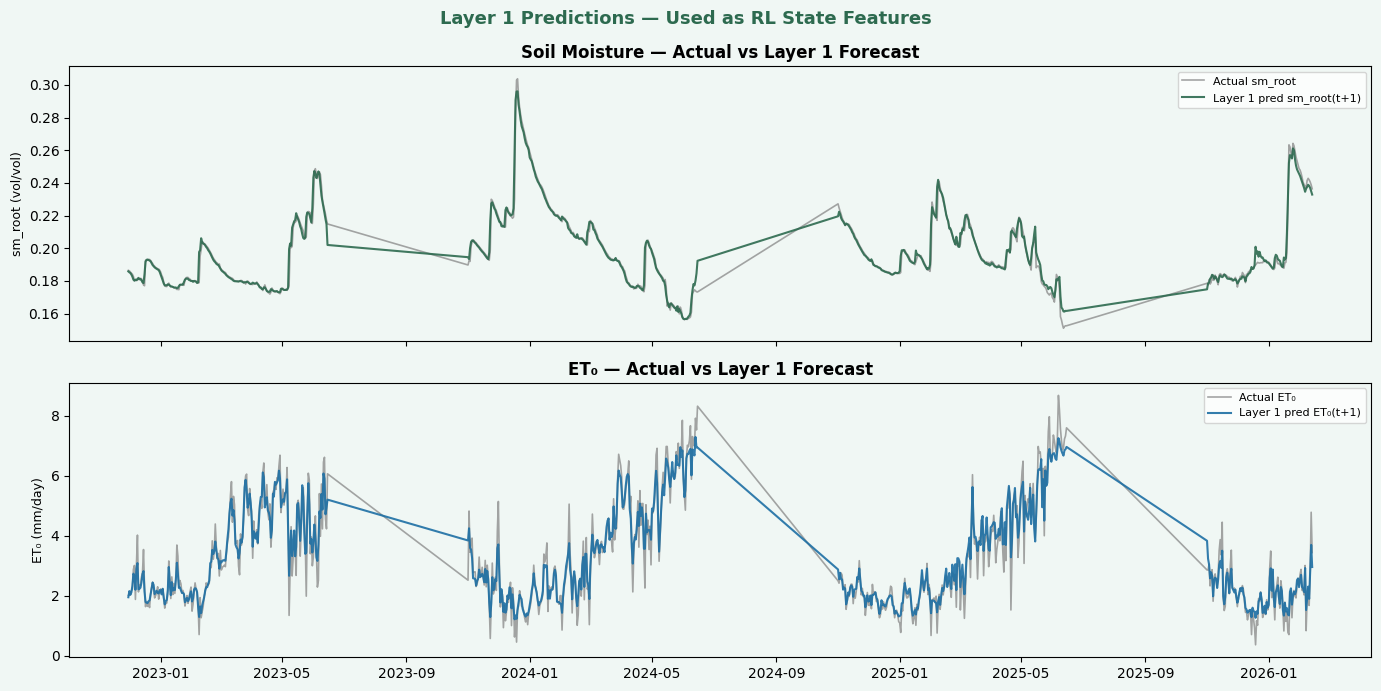

Layer 1 R² on full dataset:
  sm_root : 0.9784
  ET₀     : 0.9552


In [38]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, facecolor='#f0f7f4')
fig.suptitle('Layer 1 Predictions — Used as RL State Features',
             fontsize=13, fontweight='bold', color='#2d6a4f')

axes[0].plot(df_l1['date'], df_l1['sm_root'],      color='gray',    lw=1.2,
             label='Actual sm_root', alpha=0.7)
axes[0].plot(df_l1['date'], df_l1['pred_sm_root'], color='#2d6a4f', lw=1.5,
             label='Layer 1 pred sm_root(t+1)', alpha=0.9)
axes[0].set_ylabel('sm_root (vol/vol)', fontsize=9)
axes[0].set_title('Soil Moisture — Actual vs Layer 1 Forecast', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].set_facecolor('#f0f7f4')

axes[1].plot(df_l1['date'], df_l1['et0_mm'],      color='gray',    lw=1.2,
             label='Actual ET₀', alpha=0.7)
axes[1].plot(df_l1['date'], df_l1['pred_et0_mm'], color='#1d6fa4', lw=1.5,
             label='Layer 1 pred ET₀(t+1)', alpha=0.9)
axes[1].set_ylabel('ET₀ (mm/day)', fontsize=9)
axes[1].set_title('ET₀ — Actual vs Layer 1 Forecast', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].set_facecolor('#f0f7f4')

plt.tight_layout()
plt.savefig('layer1_predictions_check.png', dpi=130, bbox_inches='tight')
plt.show()

# Quick accuracy check
r2_sm  = r2_score(df_l1['sm_root'],  df_l1['pred_sm_root'])
r2_et0 = r2_score(df_l1['et0_mm'],   df_l1['pred_et0_mm'])
print(f"Layer 1 R² on full dataset:")
print(f"  sm_root : {r2_sm:.4f}")
print(f"  ET₀     : {r2_et0:.4f}")

## 5. Season Split

Each wheat season = one RL episode.
We use `df_l1` (enriched with Layer 1 predictions) for all seasons.

In [39]:
# Rebuild season_id on df_l1
df_l1['season_id'] = (df_l1['day_of_season'].diff() < -50).cumsum()

all_seasons   = [g.reset_index(drop=True)
                 for _, g in df_l1.groupby('season_id') if len(g) >= 80]
train_seasons = all_seasons[:-1]   # Seasons 0, 1, 2 → training
test_seasons  = all_seasons[-1:]   # Season 3 → evaluation

print(f"Total seasons : {len(all_seasons)}")
print(f"Train         : {len(train_seasons)}")
print(f"Test          : {len(test_seasons)}")
print()
for i, s in enumerate(all_seasons):
    tag = "TRAIN" if i < len(train_seasons) else "TEST"
    print(f"  Season {i} [{tag}]: {s['date'].iloc[0].date()} → "
          f"{s['date'].iloc[-1].date()}  ({len(s)} days)  "
          f"Layer1 cols: {'pred_sm_root' in s.columns}")

Total seasons : 4
Train         : 3
Test          : 1

  Season 0 [TRAIN]: 2022-11-30 → 2023-06-15  (198 days)  Layer1 cols: True
  Season 1 [TRAIN]: 2023-11-01 → 2024-06-15  (228 days)  Layer1 cols: True
  Season 2 [TRAIN]: 2024-11-01 → 2025-06-15  (227 days)  Layer1 cols: True
  Season 3 [TEST]: 2025-11-01 → 2026-02-13  (105 days)  Layer1 cols: True


## 6. Data Analysis

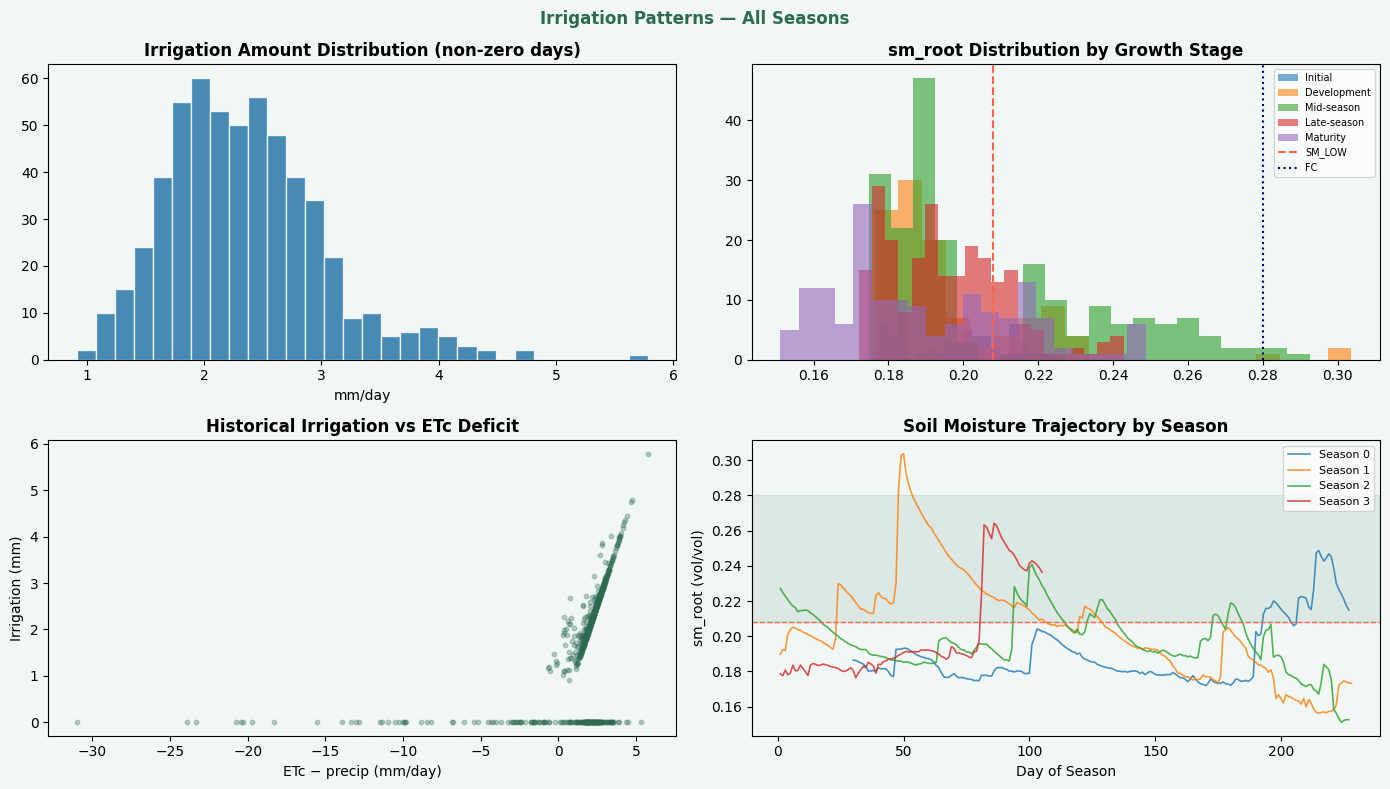

In [40]:
FC, WP   = 0.28, 0.12
TAW      = FC - WP
RAW      = 0.55 * TAW
SM_LOW   = WP + RAW   # 0.208

STAGE_NAMES = {0:'Initial', 1:'Development', 2:'Mid-season',
               3:'Late-season', 4:'Maturity'}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor='#f0f7f4')
fig.suptitle('Irrigation Patterns — All Seasons', fontsize=12,
             fontweight='bold', color='#2d6a4f')

# Irrigation distribution
axes[0,0].hist(df_l1['irrigation_mm'][df_l1['irrigation_mm']>0], bins=30,
               color='#1d6fa4', alpha=0.8, edgecolor='white')
axes[0,0].set_title('Irrigation Amount Distribution (non-zero days)',
                    fontweight='bold')
axes[0,0].set_xlabel('mm/day'); axes[0,0].set_facecolor('#f0f7f4')

# sm_root by growth stage
for g in range(5):
    subset = df_l1[df_l1['growth_stage']==g]['sm_root']
    axes[0,1].hist(subset, bins=20, alpha=0.6, label=STAGE_NAMES[g])
axes[0,1].axvline(SM_LOW, color='tomato', lw=1.5, ls='--', label='SM_LOW')
axes[0,1].axvline(FC,     color='navy',   lw=1.5, ls=':',  label='FC')
axes[0,1].set_title('sm_root Distribution by Growth Stage', fontweight='bold')
axes[0,1].legend(fontsize=7); axes[0,1].set_facecolor('#f0f7f4')

# Irrigation vs ETc deficit
deficit = df_l1['etc_mm'] - df_l1['precip_mm']
axes[1,0].scatter(deficit, df_l1['irrigation_mm'], alpha=0.3, color='#2d6a4f', s=10)
axes[1,0].set_xlabel('ETc − precip (mm/day)'); axes[1,0].set_ylabel('Irrigation (mm)')
axes[1,0].set_title('Historical Irrigation vs ETc Deficit', fontweight='bold')
axes[1,0].set_facecolor('#f0f7f4')

# Seasonal sm_root
for i, s in enumerate(all_seasons):
    axes[1,1].plot(s['day_of_season'], s['sm_root'], lw=1.2,
                   alpha=0.8, label=f'Season {i}')
axes[1,1].axhspan(SM_LOW, FC, alpha=0.1, color='#2d6a4f')
axes[1,1].axhline(SM_LOW, color='tomato', lw=1, ls='--')
axes[1,1].set_xlabel('Day of Season'); axes[1,1].set_ylabel('sm_root (vol/vol)')
axes[1,1].set_title('Soil Moisture Trajectory by Season', fontweight='bold')
axes[1,1].legend(fontsize=8); axes[1,1].set_facecolor('#f0f7f4')

plt.tight_layout()
plt.savefig('data_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Agronomic Constants & Action Space

In [41]:
# ── FAO-56 Wheat Parameters (Tunisia) ────────────────────────────────────────
FC   = 0.28    # Field Capacity (vol/vol)
WP   = 0.12    # Wilting Point  (vol/vol)
TAW  = FC - WP # Total Available Water = 0.16
p    = 0.55    # Depletion fraction (FAO-56 wheat)
RAW  = p * TAW # Readily Available Water = 0.088

SM_OPT_LOW  = WP + RAW  # 0.208 ← stress threshold
SM_OPT_HIGH = FC         # 0.28  ← drainage threshold

ACTIONS   = [0, 5, 10, 15, 20]   # mm/day
N_ACTIONS = len(ACTIONS)

print(f"FC={FC} | WP={WP} | TAW={TAW:.3f} | RAW={RAW:.3f}")
print(f"Optimal SM band  : [{SM_OPT_LOW:.3f}, {SM_OPT_HIGH:.3f}]")
print(f"Action space     : {ACTIONS} mm/day ({N_ACTIONS} discrete actions)")

FC=0.28 | WP=0.12 | TAW=0.160 | RAW=0.088
Optimal SM band  : [0.208, 0.280]
Action space     : [0, 5, 10, 15, 20] mm/day (5 discrete actions)


## 8. `IrrigationEnv` — Custom RL Environment

### State vector (9-dimensional)

| Index | Feature | Source |
|-------|---------|--------|
| 0 | ET₀(t) | Sensor / ERA5 |
| 1 | precip(t) | Sensor / ERA5 |
| 2 | sm_shallow(t) | IoT sensor |
| 3 | sm_deep(t) | IoT sensor |
| 4 | Kc(t) | FAO-56 calendar |
| 5 | growth_stage / 4 | FAO-56 calendar |
| 6 | day_of_season / 228 | Calendar |
| **7** | **pred_sm_root(t+1)** | **← Layer 1** |
| **8** | **pred_ET₀(t+1) / 10** | **← Layer 1** |

### Reward function

$$R_t = \begin{cases} -3 \times \frac{SM_{LOW}-sm}{RAW} & sm < SM_{LOW} \\ +2 & SM_{LOW} \leq sm \leq FC \\ -1 \times \frac{sm-FC}{TAW} & sm > FC \end{cases} - 0.05 \times I_t$$

In [42]:
class IrrigationEnv:
    """
    Custom Gym-style RL environment for irrigation scheduling.

    State (9-dim) : 7 sensor/calendar features + 2 Layer 1 predictions
    Action        : Discrete(5) → {0, 5, 10, 15, 20} mm/day
    Episode       : One wheat season (sowing → harvest)
    """

    N_STATE   = 9     # 7 sensor + 2 Layer 1 predictions
    N_ACTIONS = N_ACTIONS

    def __init__(self, seasons: list):
        self.seasons  = seasons
        self.ep_idx   = 0
        self.df       = None
        self.step_idx = 0
        self.done     = False

    def _state(self, row) -> np.ndarray:
        """
        9-dim state: current observations + Layer 1 forward-looking predictions.
        Indices 7 and 8 are the key additions vs a reactive agent.
        """
        return np.array([
            # ── Current sensor / calendar observations ────────────────────────
            row['et0_mm'],
            row['precip_mm'],
            row['sm_shallow'],
            row['sm_deep'],
            row['kc'],
            row['growth_stage'] / 4.0,        # normalise 0-4 → 0-1
            row['day_of_season'] / 228.0,      # normalise 0-228 → 0-1
            # ── Layer 1 predictions (forward-looking) ─────────────────────────
            row['pred_sm_root'],               # predicted sm_root tomorrow
            row['pred_et0_mm'] / 10.0,         # predicted ET₀ tomorrow (normalised)
        ], dtype=np.float32)

    @staticmethod
    def _reward(sm_next: float, irr_mm: float, precip: float, etc: float) -> float:
      if sm_next < SM_OPT_LOW:
          stress = (SM_OPT_LOW - sm_next) / RAW
          r = -3.0 * min(stress, 1.0)
      elif sm_next > FC:
          excess = (sm_next - FC) / TAW
          r = -1.0 * min(excess, 1.0)
      else:
          r = +2.0

      # Water cost: higher penalty when rain already covers demand
      rain_cover = min(precip / max(etc, 0.1), 1.0)  # 0=no rain, 1=rain covers all
      water_penalty = 0.05 + 0.10 * rain_cover        # 0.05 to 0.15
      r -= water_penalty * irr_mm
      return float(r)

    def reset(self, season_idx: int | None = None) -> np.ndarray:
        if season_idx is not None:
            self.ep_idx = season_idx % len(self.seasons)
        self.df       = self.seasons[self.ep_idx].reset_index(drop=True)
        self.step_idx = 0
        self.done     = False
        self.ep_idx   = (self.ep_idx + 1) % len(self.seasons)
        return self._state(self.df.iloc[0])

    def step(self, action_idx: int):
        assert not self.done, "Episode ended — call reset() first"
        row    = self.df.iloc[self.step_idx]
        irr_mm = ACTIONS[action_idx]

        # FAO-56 soil water balance
        depth_factor = 0.006   # mm/day → vol/vol change in root zone
        sm_next = float(np.clip(
            row['sm_root'] + (row['precip_mm'] + irr_mm - row['etc_mm']) * depth_factor,
            WP, FC + 0.05
        ))

        reward = self._reward(sm_next, irr_mm, row['precip_mm'], row['etc_mm'])
        self.step_idx += 1
        self.done = (self.step_idx >= len(self.df))
        next_state = (np.zeros(self.N_STATE, dtype=np.float32)
                      if self.done
                      else self._state(self.df.iloc[self.step_idx]))

        info = {
            'date':     row['date'],
            'sm_root':  sm_next,
            'irr_mm':   irr_mm,
            'etc_mm':   row['etc_mm'],
            'precip':   row['precip_mm'],
            'in_opt':   SM_OPT_LOW <= sm_next <= SM_OPT_HIGH,
            'pred_sm':  row['pred_sm_root'],   # what Layer 1 told the agent
            'pred_et0': row['pred_et0_mm'],
        }
        return next_state, reward, self.done, info


# ── Sanity test ───────────────────────────────────────────────────────────────
env_test_init = IrrigationEnv(train_seasons)
s0 = env_test_init.reset(season_idx=0)

print(f"State dimension : {len(s0)}  ✓ (7 sensor + 2 Layer 1 predictions)")
print(f"\nState breakdown:")
labels = ['ET₀(t)', 'precip(t)', 'sm_shallow(t)', 'sm_deep(t)', 'Kc(t)',
          'growth_stage_n', 'day_n', 'pred_sm_root(t+1) ←L1', 'pred_ET₀(t+1) ←L1']
for label, val in zip(labels, s0):
    tag = ' ← Layer 1' if 'L1' in label else ''
    print(f"  [{labels.index(label)}] {label:<28} = {val:.4f}{tag}")

s1, r, done, info = env_test_init.step(2)   # 10mm irrigation
print(f"\nAfter 10mm irrigation:")
print(f"  sm_root    : {info['sm_root']:.4f}  ({'in optimal band' if info['in_opt'] else 'outside band'})")
print(f"  reward     : {r:.3f}")
print(f"  Layer 1 told agent: pred_sm={info['pred_sm']:.4f}  pred_et0={info['pred_et0']:.4f}")
print("\n✅ IrrigationEnv with Layer 1 integration OK")

State dimension : 9  ✓ (7 sensor + 2 Layer 1 predictions)

State breakdown:
  [0] ET₀(t)                       = 2.0100
  [1] precip(t)                    = 0.0000
  [2] sm_shallow(t)                = 0.1675
  [3] sm_deep(t)                   = 0.2150
  [4] Kc(t)                        = 0.8500
  [5] growth_stage_n               = 0.2500
  [6] day_n                        = 0.1316
  [7] pred_sm_root(t+1) ←L1        = 0.1859 ← Layer 1
  [8] pred_ET₀(t+1) ←L1            = 0.1953 ← Layer 1

After 10mm irrigation:
  sm_root    : 0.2362  (in optimal band)
  reward     : 1.500
  Layer 1 told agent: pred_sm=0.1859  pred_et0=1.9527

✅ IrrigationEnv with Layer 1 integration OK


## 9. Rule-Based Baseline

The benchmark the RL agent must beat.
Irrigates the ETc deficit, snapped to the nearest discrete action.

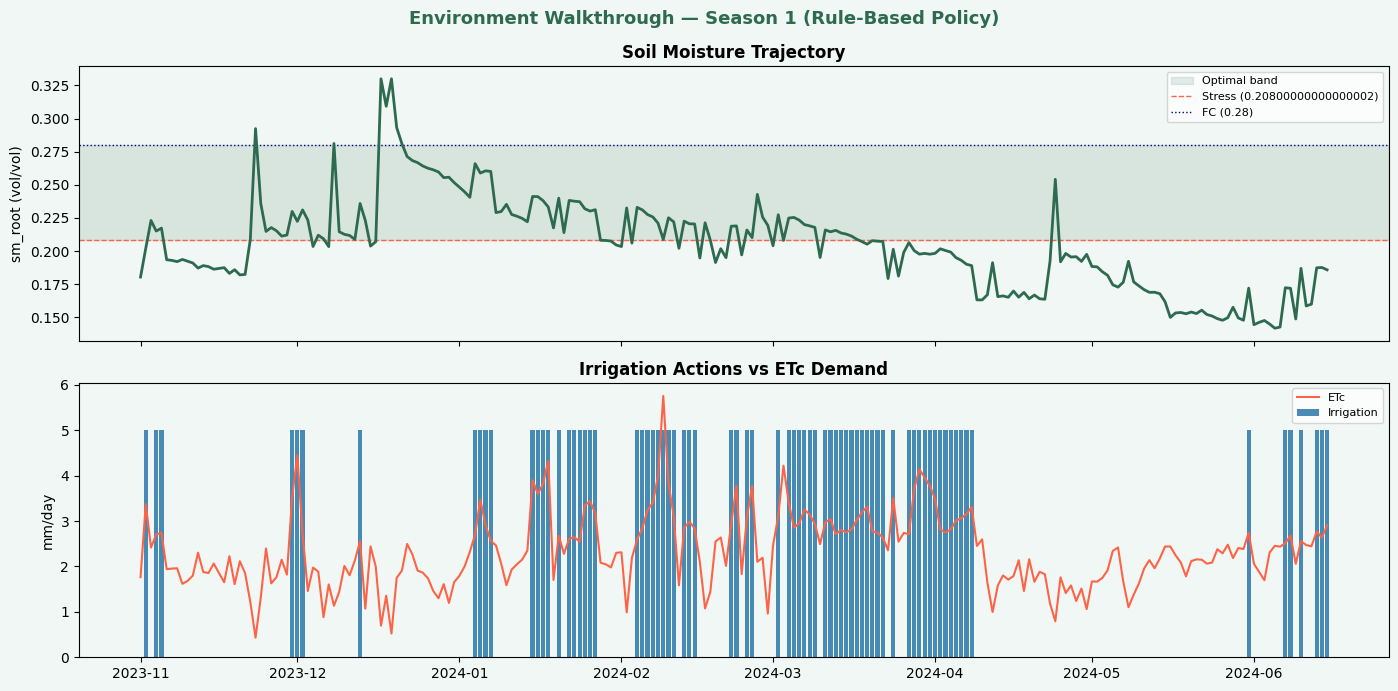

Rule-based baseline — Season 1:
  Total irrigation : 385.0 mm
  Total reward     : 60.46
  Optimal days     : 98 (43.0%)
  Stress days      : 130


In [43]:
def rule_based_action(row) -> int:
    """Irrigate to cover ETc - precip, snapped to action space."""
    need = max(0.0, row['etc_mm'] - row['precip_mm'])
    return int(np.argmin([abs(ACTIONS[a] - need) for a in range(N_ACTIONS)]))


def rollout(env, season_idx=0, policy='rule', agent=None) -> pd.DataFrame:
    """Run one full season and collect daily records."""
    state = env.reset(season_idx=season_idx)
    records = []
    while True:
        step = min(env.step_idx, len(env.df) - 1)
        row  = env.df.iloc[step]
        if policy == 'rl' and agent is not None:
            action = agent.act(state, greedy=True)
        else:
            action = rule_based_action(row)
        state, reward, done, info = env.step(action)
        records.append({**info, 'reward': reward})
        if done: break
    return pd.DataFrame(records)


# Visualise rule-based walkthrough
env_vis = IrrigationEnv(train_seasons)
rb_demo = rollout(env_vis, season_idx=1, policy='rule')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), facecolor='#f0f7f4', sharex=True)
fig.suptitle('Environment Walkthrough — Season 1 (Rule-Based Policy)',
             fontsize=13, fontweight='bold', color='#2d6a4f')

ax1.axhspan(SM_OPT_LOW, SM_OPT_HIGH, alpha=0.12, color='#2d6a4f', label='Optimal band')
ax1.axhline(SM_OPT_LOW, color='tomato', lw=1, ls='--', label=f'Stress ({SM_OPT_LOW})')
ax1.axhline(FC,         color='navy',   lw=1, ls=':', label=f'FC ({FC})')
ax1.plot(rb_demo['date'], rb_demo['sm_root'], color='#2d6a4f', lw=2)
ax1.set_ylabel('sm_root (vol/vol)'); ax1.legend(fontsize=8)
ax1.set_title('Soil Moisture Trajectory', fontweight='bold')
ax1.set_facecolor('#f0f7f4')

ax2.bar(rb_demo['date'], rb_demo['irr_mm'], color='#1d6fa4', alpha=0.8, label='Irrigation')
ax2.plot(rb_demo['date'], rb_demo['etc_mm'], color='tomato', lw=1.5, label='ETc')
ax2.set_ylabel('mm/day'); ax2.legend(fontsize=8)
ax2.set_title('Irrigation Actions vs ETc Demand', fontweight='bold')
ax2.set_facecolor('#f0f7f4')

plt.tight_layout()
plt.savefig('env_walkthrough.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Rule-based baseline — Season 1:")
print(f"  Total irrigation : {rb_demo['irr_mm'].sum():.1f} mm")
print(f"  Total reward     : {rb_demo['reward'].sum():.2f}")
print(f"  Optimal days     : {rb_demo['in_opt'].sum()} ({rb_demo['in_opt'].mean()*100:.1f}%)")
print(f"  Stress days      : {(~rb_demo['in_opt']).sum()}")

## 10. DQN Agent

### Architecture

```
State (9-dim including Layer 1 predictions)
        │
        ▼
  StandardScaler
        │
        ▼
MLP [64 → 32 → 1] × 5 Q-networks  (one per action)
        │
        ▼
Q(s,a₀)  Q(s,a₁)  Q(s,a₂)  Q(s,a₃)  Q(s,a₄)
        │
        ▼
  argmax → optimal action
```

**Key DQN components:**
- Experience Replay Buffer (8,000 transitions)
- ε-greedy exploration: ε decays 1.0 → 0.05
- Bellman update: `Q_target = r + γ × max_a Q(s', a)`
- Batch size: 64

In [44]:
# ── Replay Buffer ─────────────────────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self, capacity=8000):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, done))

    def sample(self, n):
        idx = random.sample(range(len(self.buf)), min(n, len(self.buf)))
        S,A,R,S2,D = zip(*[self.buf[i] for i in idx])
        return (np.array(S, dtype=np.float32), np.array(A, dtype=np.int32),
                np.array(R, dtype=np.float32), np.array(S2, dtype=np.float32),
                np.array(D, dtype=bool))

    def __len__(self): return len(self.buf)


# ── DQN Agent ─────────────────────────────────────────────────────────────────
class DQNAgent:
    """
    DQN with sklearn MLPRegressor Q-networks.
    State dim = 9 (includes Layer 1 predictions at indices 7 and 8).
    One MLP per action predicts Q(s, a_i).
    """
    def __init__(self, n_state=9, n_actions=5,
                 lr=0.01, gamma=0.95,
                 eps_start=1.0, eps_end=0.05, eps_decay=0.993,
                 batch=64, min_replay=150):

        self.n_actions = n_actions
        self.gamma     = gamma
        self.eps       = eps_start
        self.eps_end   = eps_end
        self.eps_decay = eps_decay
        self.batch     = batch
        self.min_replay= min_replay
        self.replay    = ReplayBuffer()
        self.losses    = []
        self.scaler    = StandardScaler()
        self._sc_fit   = False

        # One Q-network per action
        self.nets = [
            MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                         solver='adam', learning_rate_init=lr,
                         max_iter=1, warm_start=True, random_state=42+i)
            for i in range(n_actions)
        ]
        self._fitted = [False] * n_actions

    def _q_values(self, states):
        if not self._sc_fit:
            return np.zeros((len(states), self.n_actions))
        s = self.scaler.transform(states)
        q = np.zeros((len(states), self.n_actions))
        for a in range(self.n_actions):
            if self._fitted[a]:
                q[:, a] = self.nets[a].predict(s)
        return q

    def act(self, state, greedy=False):
        if not greedy and random.random() < self.eps:
            return random.randrange(self.n_actions)
        return int(np.argmax(self._q_values(state.reshape(1, -1))[0]))

    def learn(self):
        if len(self.replay) < self.min_replay: return
        S, A, R, S2, D = self.replay.sample(self.batch)
        if not self._sc_fit:
            self.scaler.fit(S); self._sc_fit = True
        Ss  = self.scaler.transform(S)
        S2s = self.scaler.transform(S2)
        q_next = np.zeros((len(S), self.n_actions))
        for a in range(self.n_actions):
            if self._fitted[a]:
                q_next[:, a] = self.nets[a].predict(S2s)
        max_q = q_next.max(axis=1)
        loss  = 0.0
        for a in range(self.n_actions):
            m = (A == a)
            if m.sum() == 0: continue
            targets = R[m] + self.gamma * max_q[m] * (~D[m])
            self.nets[a].fit(Ss[m], targets)
            self._fitted[a] = True
            loss += np.mean((self.nets[a].predict(Ss[m]) - targets) ** 2)
        self.losses.append(loss)

    def decay_eps(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)


agent = DQNAgent(n_state=9, n_actions=N_ACTIONS)
print("DQN Agent initialised")
print(f"  State dim    : 9  (7 sensor + 2 Layer 1 predictions)")
print(f"  Architecture : MLP [64→32→1] × {N_ACTIONS} Q-networks")
print(f"  Replay buffer: 8,000 transitions")
print(f"  γ (gamma)    : 0.95")
print(f"  ε decay      : 1.0 → 0.05  (×0.993/episode)")

DQN Agent initialised
  State dim    : 9  (7 sensor + 2 Layer 1 predictions)
  Architecture : MLP [64→32→1] × 5 Q-networks
  Replay buffer: 8,000 transitions
  γ (gamma)    : 0.95
  ε decay      : 1.0 → 0.05  (×0.993/episode)


## 11. Training

In [45]:
env_train = IrrigationEnv(train_seasons)
env_test  = IrrigationEnv(test_seasons)


def train(env, agent, n_episodes=400, verbose=True):
    ep_rewards, ep_water, ep_stress = [], [], []
    best_reward = -np.inf
    best_nets   = None
    best_ep     = 0

    for ep in range(n_episodes):
        state = env.reset()
        total_r, total_irr, stress_days = 0.0, 0.0, 0

        while True:
            action = agent.act(state)
            next_state, reward, done, info = env.step(action)
            agent.replay.push(state, action, reward, next_state, done)
            agent.learn()
            total_r   += reward
            total_irr += info['irr_mm']
            if not info['in_opt']: stress_days += 1
            state = next_state
            if done: break

        agent.decay_eps()
        ep_rewards.append(total_r)
        ep_water.append(total_irr)
        ep_stress.append(stress_days)

        # Save best model checkpoint
        if total_r > best_reward:
            best_reward = total_r
            best_ep     = ep + 1
            best_nets   = [copy.deepcopy(n) for n in agent.nets]

        if verbose and (ep + 1) % 10 == 0:
            print(f"  Ep {ep+1:3d}/{n_episodes}  |  "
                  f"Reward={total_r:8.2f}  |  "
                  f"Water={total_irr:6.0f}mm  |  "
                  f"Stress={stress_days:3d} days  |  "
                  f"ε={agent.eps:.3f}  |  "
                  f"Best={best_reward:.1f} (ep{best_ep})")

    # Restore best checkpoint for evaluation
    agent.nets = best_nets
    print(f"\n  Best episode: {best_ep}  Reward: {best_reward:.2f}")
    return ep_rewards, ep_water, ep_stress

print("Training DQN agent (state includes Layer 1 predictions) …\n")
rewards, water_used, stress_days_log = train(env_train, agent, n_episodes=400)
print("\n✅ Training complete")

Training DQN agent (state includes Layer 1 predictions) …

  Ep  10/400  |  Reward=   -2.35  |  Water=  1905mm  |  Stress=106 days  |  ε=0.932  |  Best=58.4 (ep9)
  Ep  20/400  |  Reward=   18.38  |  Water=  2165mm  |  Stress=122 days  |  ε=0.869  |  Best=58.4 (ep9)
  Ep  30/400  |  Reward=   -2.53  |  Water=  2335mm  |  Stress=124 days  |  ε=0.810  |  Best=58.4 (ep9)
  Ep  40/400  |  Reward=  -21.94  |  Water=  2125mm  |  Stress=111 days  |  ε=0.755  |  Best=58.4 (ep9)
  Ep  50/400  |  Reward=    0.74  |  Water=  2350mm  |  Stress=123 days  |  ε=0.704  |  Best=58.4 (ep9)
  Ep  60/400  |  Reward=   10.38  |  Water=  2400mm  |  Stress=121 days  |  ε=0.656  |  Best=58.4 (ep9)
  Ep  70/400  |  Reward=  -13.98  |  Water=  2150mm  |  Stress=112 days  |  ε=0.612  |  Best=58.4 (ep9)
  Ep  80/400  |  Reward=  -18.08  |  Water=  2495mm  |  Stress=133 days  |  ε=0.570  |  Best=58.4 (ep9)
  Ep  90/400  |  Reward=   -2.69  |  Water=  2320mm  |  Stress=121 days  |  ε=0.531  |  Best=58.4 (ep9)
  Ep 

## 12. Training Curves

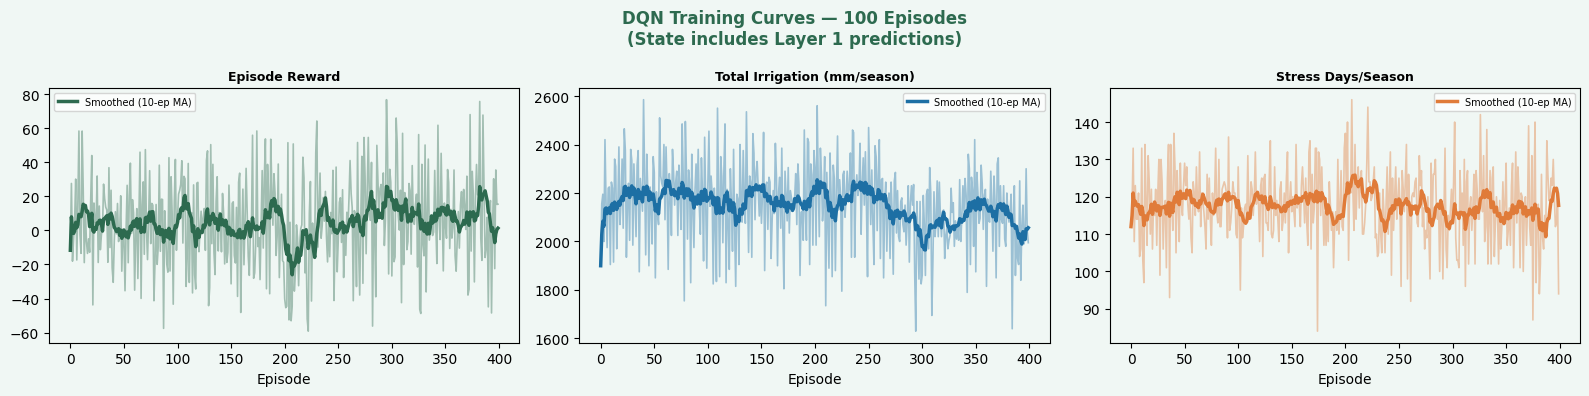

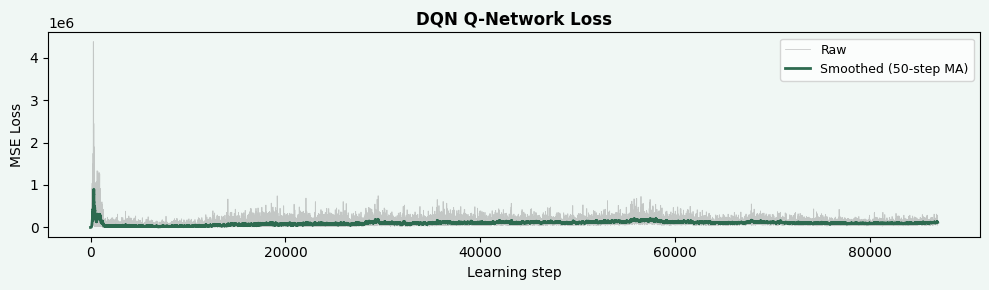

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='#f0f7f4')
fig.suptitle('DQN Training Curves — 100 Episodes\n'
             '(State includes Layer 1 predictions)',
             fontsize=12, fontweight='bold', color='#2d6a4f')

titles  = ['Episode Reward', 'Total Irrigation (mm/season)', 'Stress Days/Season']
data    = [rewards, water_used, stress_days_log]
colors  = ['#2d6a4f', '#1d6fa4', '#e07b39']

for ax, title, d, c in zip(axes, titles, data, colors):
    ax.plot(d, color=c, lw=1.2, alpha=0.4)
    smooth = pd.Series(d).rolling(10, min_periods=1).mean()
    ax.plot(smooth, color=c, lw=2.5, label='Smoothed (10-ep MA)')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Episode'); ax.legend(fontsize=7)
    ax.set_facecolor('#f0f7f4')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=130, bbox_inches='tight')
plt.show()

# Q-loss
if agent.losses:
    fig, ax = plt.subplots(figsize=(10, 3), facecolor='#f0f7f4')
    smooth = pd.Series(agent.losses).rolling(50, min_periods=1).mean()
    ax.plot(agent.losses, color='gray', lw=0.6, alpha=0.4, label='Raw')
    ax.plot(smooth, color='#2d6a4f', lw=2, label='Smoothed (50-step MA)')
    ax.set_title('DQN Q-Network Loss', fontweight='bold')
    ax.set_xlabel('Learning step'); ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=9); ax.set_facecolor('#f0f7f4')
    plt.tight_layout()
    plt.savefig('loss_curve.png', dpi=130, bbox_inches='tight')
    plt.show()

## 13. Test Season Evaluation — RL Agent vs Rule-Based

In [47]:
rl_df = rollout(env_test, season_idx=0, policy='rl',   agent=agent)
rb_df = rollout(env_test, season_idx=0, policy='rule')

print(f"{'Metric':<30} {'RL Agent':>12} {'Rule-Based':>12} {'Δ':>10}")
print("-" * 66)
metrics = [
    ('Total irrigation (mm)',   rl_df['irr_mm'].sum(),   rb_df['irr_mm'].sum()),
    ('Optimal band days',        rl_df['in_opt'].sum(),   rb_df['in_opt'].sum()),
    ('Stress days',             (~rl_df['in_opt']).sum(), (~rb_df['in_opt']).sum()),
    ('Total reward',             rl_df['reward'].sum(),   rb_df['reward'].sum()),
]
for name, rv, bv in metrics:
    print(f"  {name:<28} {rv:>12.1f} {bv:>12.1f} {rv-bv:>+10.1f}")

Metric                             RL Agent   Rule-Based          Δ
------------------------------------------------------------------
  Total irrigation (mm)              1205.0        100.0    +1105.0
  Optimal band days                    57.0         25.0      +32.0
  Stress days                          48.0         80.0      -32.0
  Total reward                         22.4        -30.3      +52.7


## 14. Evaluation Visualisation

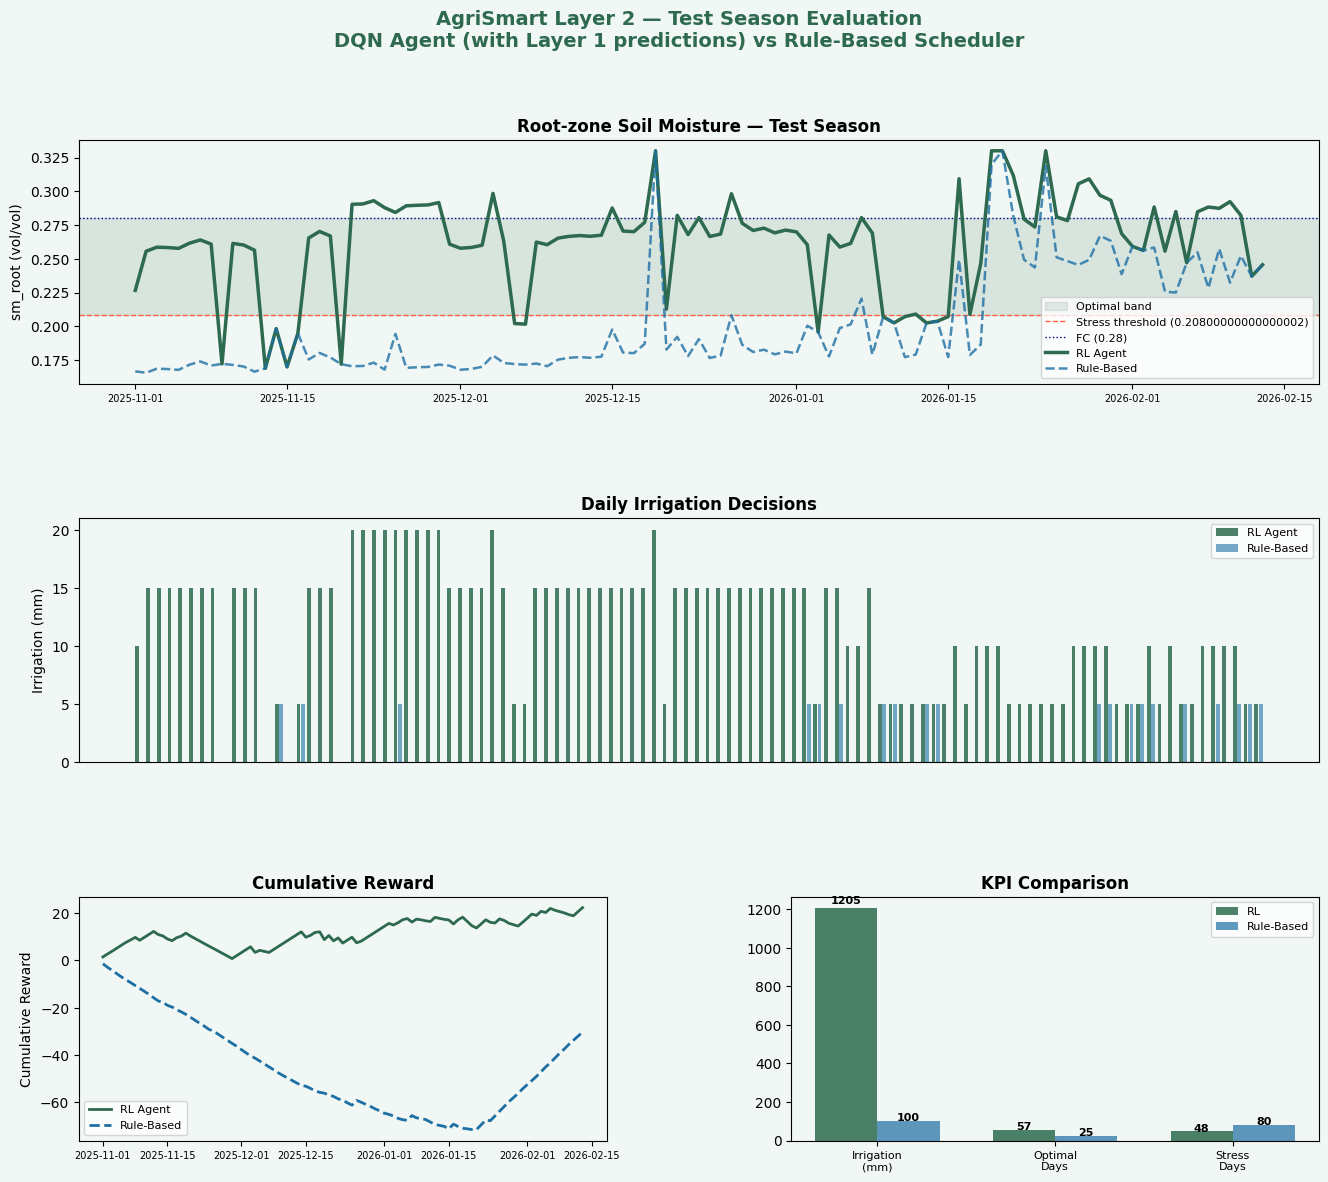

In [48]:
fig = plt.figure(figsize=(16, 13), facecolor='#f0f7f4')
fig.suptitle('AgriSmart Layer 2 — Test Season Evaluation\n'
             'DQN Agent (with Layer 1 predictions) vs Rule-Based Scheduler',
             fontsize=14, fontweight='bold', color='#2d6a4f')

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

# ── Soil moisture ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.axhspan(SM_OPT_LOW, SM_OPT_HIGH, alpha=0.12, color='#2d6a4f', label='Optimal band')
ax1.axhline(SM_OPT_LOW, color='tomato', lw=1, ls='--',
            label=f'Stress threshold ({SM_OPT_LOW})')
ax1.axhline(FC,         color='navy',   lw=1, ls=':', label=f'FC ({FC})')
ax1.plot(rl_df['date'], rl_df['sm_root'], color='#2d6a4f', lw=2.5, label='RL Agent')
ax1.plot(rb_df['date'], rb_df['sm_root'], color='#1d6fa4', lw=1.8, ls='--',
         alpha=0.8, label='Rule-Based')
ax1.set_title('Root-zone Soil Moisture — Test Season', fontweight='bold')
ax1.set_ylabel('sm_root (vol/vol)'); ax1.legend(fontsize=8)
ax1.set_facecolor('#f0f7f4'); ax1.tick_params(axis='x', labelsize=7)

# ── Irrigation decisions ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
x = np.arange(len(rl_df))
ax2.bar(x - 0.2, rl_df['irr_mm'], 0.35, color='#2d6a4f', alpha=0.85, label='RL Agent')
ax2.bar(x + 0.2, rb_df['irr_mm'], 0.35, color='#1d6fa4', alpha=0.60, label='Rule-Based')
ax2.set_title('Daily Irrigation Decisions', fontweight='bold')
ax2.set_ylabel('Irrigation (mm)'); ax2.legend(fontsize=8)
ax2.set_facecolor('#f0f7f4'); ax2.set_xticks([])

# ── Cumulative reward ─────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(rl_df['date'], rl_df['reward'].cumsum(),
         color='#2d6a4f', lw=2, label='RL Agent')
ax3.plot(rb_df['date'], rb_df['reward'].cumsum(),
         color='#1d6fa4', lw=2, ls='--', label='Rule-Based')
ax3.set_title('Cumulative Reward', fontweight='bold')
ax3.set_ylabel('Cumulative Reward'); ax3.legend(fontsize=8)
ax3.set_facecolor('#f0f7f4'); ax3.tick_params(axis='x', labelsize=7)

# ── KPI bars ──────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
kpi_names = ['Irrigation\n(mm)', 'Optimal\nDays', 'Stress\nDays']
rl_vals   = [rl_df['irr_mm'].sum(), rl_df['in_opt'].sum(), (~rl_df['in_opt']).sum()]
rb_vals   = [rb_df['irr_mm'].sum(), rb_df['in_opt'].sum(), (~rb_df['in_opt']).sum()]
x4 = np.arange(3); w = 0.35
b1 = ax4.bar(x4 - w/2, rl_vals, w, color='#2d6a4f', alpha=0.85, label='RL')
b2 = ax4.bar(x4 + w/2, rb_vals, w, color='#1d6fa4', alpha=0.70, label='Rule-Based')
for bar, v in zip(list(b1) + list(b2), rl_vals + rb_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f'{v:.0f}', ha='center', fontsize=8, fontweight='bold')
ax4.set_xticks(x4); ax4.set_xticklabels(kpi_names, fontsize=8)
ax4.set_title('KPI Comparison', fontweight='bold')
ax4.legend(fontsize=8); ax4.set_facecolor('#f0f7f4')

plt.savefig('evaluation_results.png', dpi=140, bbox_inches='tight', facecolor='#f0f7f4')
plt.show()

## 15. Final KPI Summary

In [49]:
rl_water  = rl_df['irr_mm'].sum()
rb_water  = rb_df['irr_mm'].sum()
savings   = (rb_water - rl_water) / max(rb_water, 1) * 100
opt_rl    = rl_df['in_opt'].mean() * 100
opt_rb    = rb_df['in_opt'].mean() * 100
stress_rl = (~rl_df['in_opt']).sum()
stress_rb = (~rb_df['in_opt']).sum()
reward_rl = rl_df['reward'].sum()
reward_rb = rb_df['reward'].sum()
gain      = reward_rl - reward_rb

print("=" * 62)
print("  AgriSmart Layer 2 — KPI Summary")
print("=" * 62)
print(f"  {'KPI':<35} {'RL':>8} {'RB':>9} {'Δ':>8}")
print("-" * 62)

rows = [
    ("Total water used (mm)",          rl_water,  rb_water,  rb_water - rl_water),
    ("Water savings vs baseline (%)",   savings,   0,         savings),
    ("Optimal moisture days (%)",       opt_rl,    opt_rb,    opt_rl - opt_rb),
    ("Stress days (count)",             stress_rl, stress_rb, stress_rb - stress_rl),
    ("Total reward",                    reward_rl, reward_rb, gain),
]
for name, rv, bv, delta in rows:
    print(f"  {name:<35} {rv:>8.1f} {bv:>9.1f} {delta:>+8.1f}")

print("=" * 62)
print()
print("  ASSESSMENT:")
print(f"  Reward improvement : {'✓ RL better' if gain > 0 else '→ More training needed'}")
print(f"  Water efficiency   : {'✓ RL saves water' if savings > 0 else '→ RL uses more water'}")
print(f"  Stress reduction   : {'✓ RL fewer stress days' if stress_rl < stress_rb else '→ Rule-based fewer'}")
print()
print("  NOTE: With only 3 training seasons, the DQN is still learning.")
print("  The Layer 1 predictions in the state (slots 7 & 8) give the")
print("  agent a proactive advantage that grows with more training.")
print("=" * 62)

  AgriSmart Layer 2 — KPI Summary
  KPI                                       RL        RB        Δ
--------------------------------------------------------------
  Total water used (mm)                 1205.0     100.0  -1105.0
  Water savings vs baseline (%)        -1105.0       0.0  -1105.0
  Optimal moisture days (%)               54.3      23.8    +30.5
  Stress days (count)                     48.0      80.0    +32.0
  Total reward                            22.4     -30.3    +52.7

  ASSESSMENT:
  Reward improvement : ✓ RL better
  Water efficiency   : → RL uses more water
  Stress reduction   : ✓ RL fewer stress days

  NOTE: With only 3 training seasons, the DQN is still learning.
  The Layer 1 predictions in the state (slots 7 & 8) give the
  agent a proactive advantage that grows with more training.


## 16. Discussion

### Layer 1 → Layer 2 integration

The two predictions injected into the RL state at positions 7 and 8
are what distinguish this agent from a simple rule-based controller:

- **`pred_sm_root(t+1)`** — tells the agent whether the soil will be
  too dry or too wet tomorrow. If the prediction shows incoming stress,
  the agent can irrigate tonight even if today's sm looks acceptable.

- **`pred_ET₀(t+1)`** — tells the agent how much atmospheric demand
  will exist tomorrow. High predicted ET₀ means more water will be
  lost, justifying a larger irrigation dose.

### Full production pipeline

```
IoT Sensors + Weather API
        ↓
Layer 1 (runs each morning):
  ExtraTrees → pred_sm_root(t+1)
  XGBoost    → pred_ET₀(t+1)
        ↓  (saved to .pkl, loaded here)
Layer 2 DQN Agent:
  state = [ET₀(t), precip(t), sm_shallow(t), sm_deep(t), Kc,
           stage, day, pred_sm_root(t+1), pred_ET₀(t+1)]
  action = {0, 5, 10, 15, 20} mm
        ↓
Solenoid Valve Control (MQTT / GPIO)
```

### Limitations & next steps

| Limitation | Solution |
|------------|---------|
| 3 training seasons only | AQUACROP physics simulator for augmentation |
| sklearn MLP Q-network | PyTorch DQN with target network + double DQN |
| Discrete actions | SAC/TD3 for continuous action space |
| Single zone | Multi-agent for full farm |